**Cardiovascular disease diagnosis: a holistic approach using the integration of machine learning and deep learning models**


H. Sadr, A. Salari, M. T. Ashoobi, and M. Nazari, “Cardiovascular disease diagnosis: a holistic approach using the integration of machine learning and deep learning models,” European Journal of Medical Research, vol. 29, no. 1, Sep. 2024, doi: 10.1186/s40001-024-02044-7.


Proposed model:

**CNN-LSTM+XGB+KNN**

In [ ]:
!pip install alibi

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.3 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of thinc to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of thinc to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you want to abort this run, press Ctrl + C.
INFO: pip is looking at multiple versions of spacy[lookups] to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 522.1/522.1 kB 28.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.8/60.8 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 98.1 MB/s eta 0:00:00

In [ ]:
!pip install lime shap scikit-learn numpy pandas matplotlib tensorflow pillow


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 13.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=2314c6fe5e6add1ee0c71b83ed45b08b07ce4a68a6aba9cf4166d3d3e427ba17
  Stored in directory: /root/.cache/pip/wheels/85/fa/a3/9c2d44c9f3cd77cf4e533b58900b2bf4487f2a17e8ec212a3d
Successfully built lime


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import learning_curve
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, BatchNormalization, LSTM
from tensorflow.keras.layers import Flatten, Dropout, Dense
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, accuracy_score,classification_report
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from tensorflow.keras.optimizers import Adam
from keras.callbacks import EarlyStopping


In [ ]:
from lime.lime_tabular import LimeTabularExplainer


In [4]:
df=pd.read_csv('cardio_train.csv',sep=";")
df

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,19240,2,168,76.0,120,80,1,1,1,0,1,0
69996,99995,22601,1,158,126.0,140,90,2,2,0,0,1,1
69997,99996,19066,2,183,105.0,180,90,3,1,0,1,0,1
69998,99998,22431,1,163,72.0,135,80,1,2,0,0,0,1


In [5]:
print(df.duplicated().sum())
print("_________________________________________________________________")
print(df.isnull().sum())
print("_________________________________________________________________")

print(df.info())
print("_______________________________________________________________")

print(df.describe())
df['age'] = df['age']/ 365
df.drop("id",axis=1,inplace= True)

0
_________________________________________________________________
id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64
_________________________________________________________________
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         7

In [6]:
df

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,50.391781,2,168,62.0,110,80,1,1,0,0,1,0
1,55.419178,1,156,85.0,140,90,3,1,0,0,1,1
2,51.663014,1,165,64.0,130,70,3,1,0,0,0,1
3,48.282192,2,169,82.0,150,100,1,1,0,0,1,1
4,47.873973,1,156,56.0,100,60,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
69995,52.712329,2,168,76.0,120,80,1,1,1,0,1,0
69996,61.920548,1,158,126.0,140,90,2,2,0,0,1,1
69997,52.235616,2,183,105.0,180,90,3,1,0,1,0,1
69998,61.454795,1,163,72.0,135,80,1,2,0,0,0,1


In [8]:
x= df.drop(['cardio'], axis=1)
y= df['cardio']


In [9]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)
xexpand= np.expand_dims(x_scaled, axis=2)

In [10]:

x_trainexpand, x_testexpand, y_train, y_test = train_test_split(xexpand, y, test_size=0.2, random_state=0)

x_train2= x_trainexpand.squeeze(axis=2)
x_test2 = x_testexpand.squeeze(axis=2)


In [11]:


model= Sequential()
model.add(Conv1D(filters=6, kernel_size=3, activation='relu', input_shape=(x_trainexpand.shape[1], 1)))
model.add(MaxPooling1D(pool_size=2))
model.add(Conv1D(filters=10, kernel_size=3, activation='relu'))

model.add(BatchNormalization())
model.add(MaxPooling1D(pool_size=2))

model.add(LSTM(8, return_sequences=False))
model.add(BatchNormalization())
model.add(Flatten())
model.add(Dropout(0.2))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer=Adam(learning_rate=0.01), loss='binary_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
model.fit(x_trainexpand, y_train, epochs=50, batch_size=10, validation_split=0.2, callbacks=[early_stop], verbose=1)

firstprob = model.predict(x_testexpand).flatten()



/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
4480/4480 ━━━━━━━━━━━━━━━━━━━━ 21s 4ms/step - accuracy: 0.6408 - loss: 0.6440 - val_accuracy: 0.7254 - val_loss: 0.5531
Epoch 2/50
4480/4480 ━━━━━━━━━━━━━━━━━━━━ 17s 4ms/step - accuracy: 0.7114 - loss: 0.5855 - val_accuracy: 0.7263 - val_loss: 0.5563
Epoch 3/50
4480/4480 ━━━━━━━━━━━━━━━━━━━━ 21s 4ms/step - accuracy: 0.7158 - loss: 0.5787 - val_accuracy: 0.7229 - val_loss: 0.5745
Epoch 4/50
4480/4480 ━━━━━━━━━━━━━━━━━━━━ 17s 4ms/step - accuracy: 0.7158 - loss: 0.5801 - val_accuracy: 0.7075 - val_loss: 0.5778
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [12]:
knn = KNeighborsClassifier(n_neighbors=5, weights='distance', algorithm='auto', metric='euclidean')
knn.fit(x_train2, y_train)
knnprob= knn.predict_proba(x_test2)[:, 1]


In [13]:
xgb = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, subsample=1.0,random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb.fit(x_train2, y_train)
xgbpro = xgb.predict_proba(x_test2)[:, 1]

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [15:34:12] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


In [14]:
probFinal = (0.42* firstprob + 0.08* knnprob +0.5* xgbpro)
y_predFinal= (probFinal >= 0.5).astype(int)
accuracy = accuracy_score(y_test, y_predFinal)
print("the final accuracy", accuracy)

the final accuracy 0.7317142857142858


In [15]:
print("\n______test classification report_______________________________\n", classification_report(y_test, y_predFinal))



______test classification report_______________________________
               precision    recall  f1-score   support

           0       0.72      0.78      0.75      7069
           1       0.75      0.68      0.72      6931

    accuracy                           0.73     14000
   macro avg       0.73      0.73      0.73     14000
weighted avg       0.73      0.73      0.73     14000



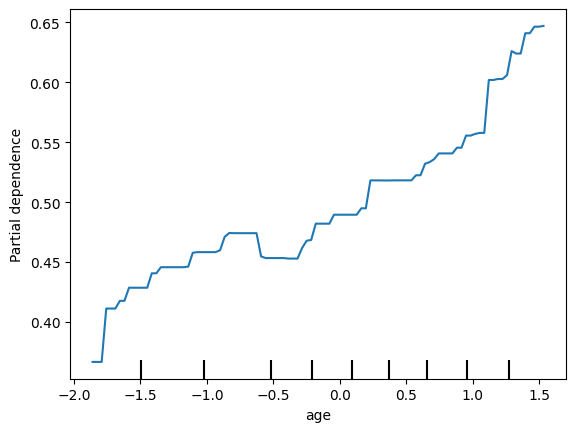

In [ ]:
from sklearn.datasets import make_hastie_10_2
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.inspection import PartialDependenceDisplay
feature = ['age','gender',	'height',	'weight','ap_hi','ap_lo','cholesterol','gluc','smoke','alco'	,'active']
features = [0]
PartialDependenceDisplay.from_estimator(xgb , x_test2, features,feature_names=feature);


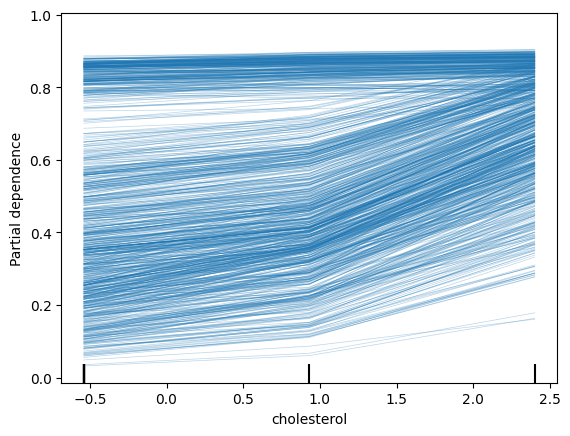

In [ ]:
features = [6]


PartialDependenceDisplay.from_estimator(xgb,x_test2,features,feature_names=feature,kind="individual")

In [ ]:
!pip install shap

In [ ]:
import shap

 96%|=================== | 13507/14000 [00:19<00:00]       

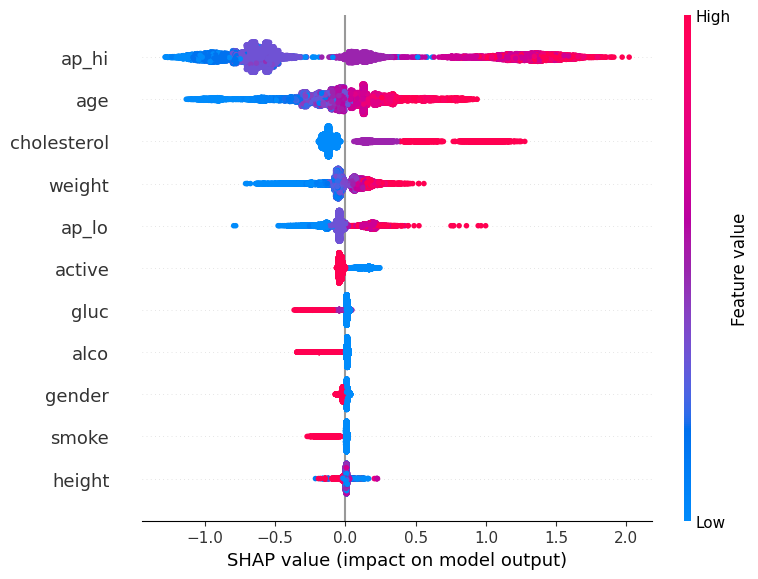

In [ ]:
features=['age','gender',	'height',	'weight','ap_hi','ap_lo','cholesterol','gluc','smoke','alco'	,'active']
explainer2 = shap.Explainer(xgb, pd.DataFrame(x_train2, columns=features))
shap_values2 = explainer2(pd.DataFrame(x_test2, columns=features))
shap.summary_plot(shap_values2, pd.DataFrame(x_test2, columns=features))


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [16:57:05] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [16:57:05] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [16:57:05] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [16:57:05] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [16:57:05] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_e

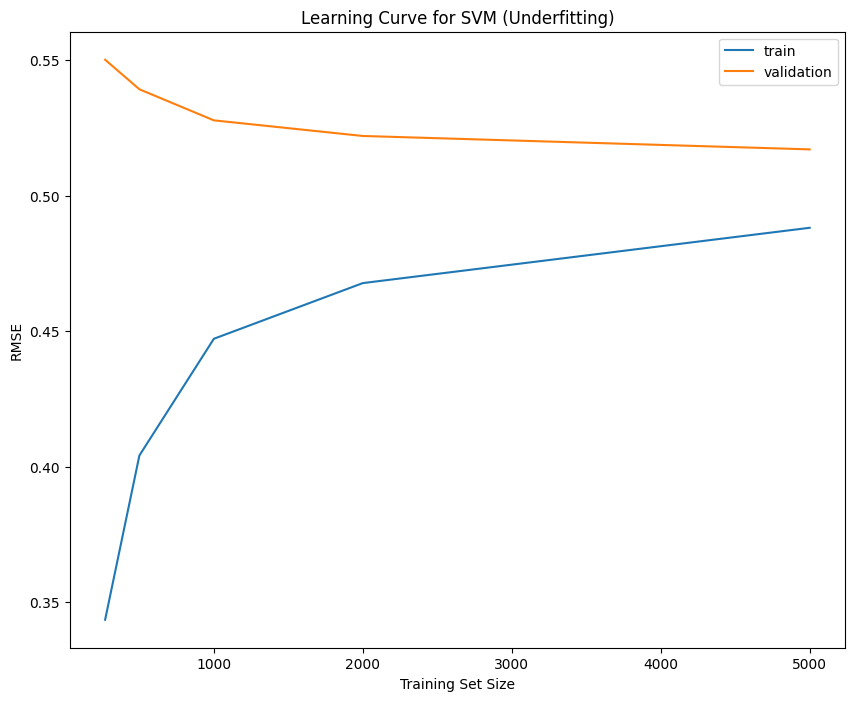

In [ ]:
train_sizes, train_scores, test_scores = learning_curve(
    estimator=xgb,
    X=x_train2,
    y=y_train,
    cv=5,
    scoring="neg_root_mean_squared_error",
    train_sizes = [1, 270,500,1000,2000,5000]
)

train_mean = -train_scores.mean(axis=1)
test_mean = -test_scores.mean(axis=1)

plt.subplots(figsize=(10,8))
plt.plot(train_sizes, train_mean, label="train")
plt.plot(train_sizes, test_mean, label="validation")

plt.title("Learning Curve for SVM (Underfitting)")
plt.xlabel("Training Set Size")
plt.ylabel("RMSE")
plt.legend(loc="best")

plt.show()

In [ ]:
import alibi.explainers

In [ ]:
from alibi.explainers import ALE , plot_ale

In [ ]:
prob=xgb.predict_proba

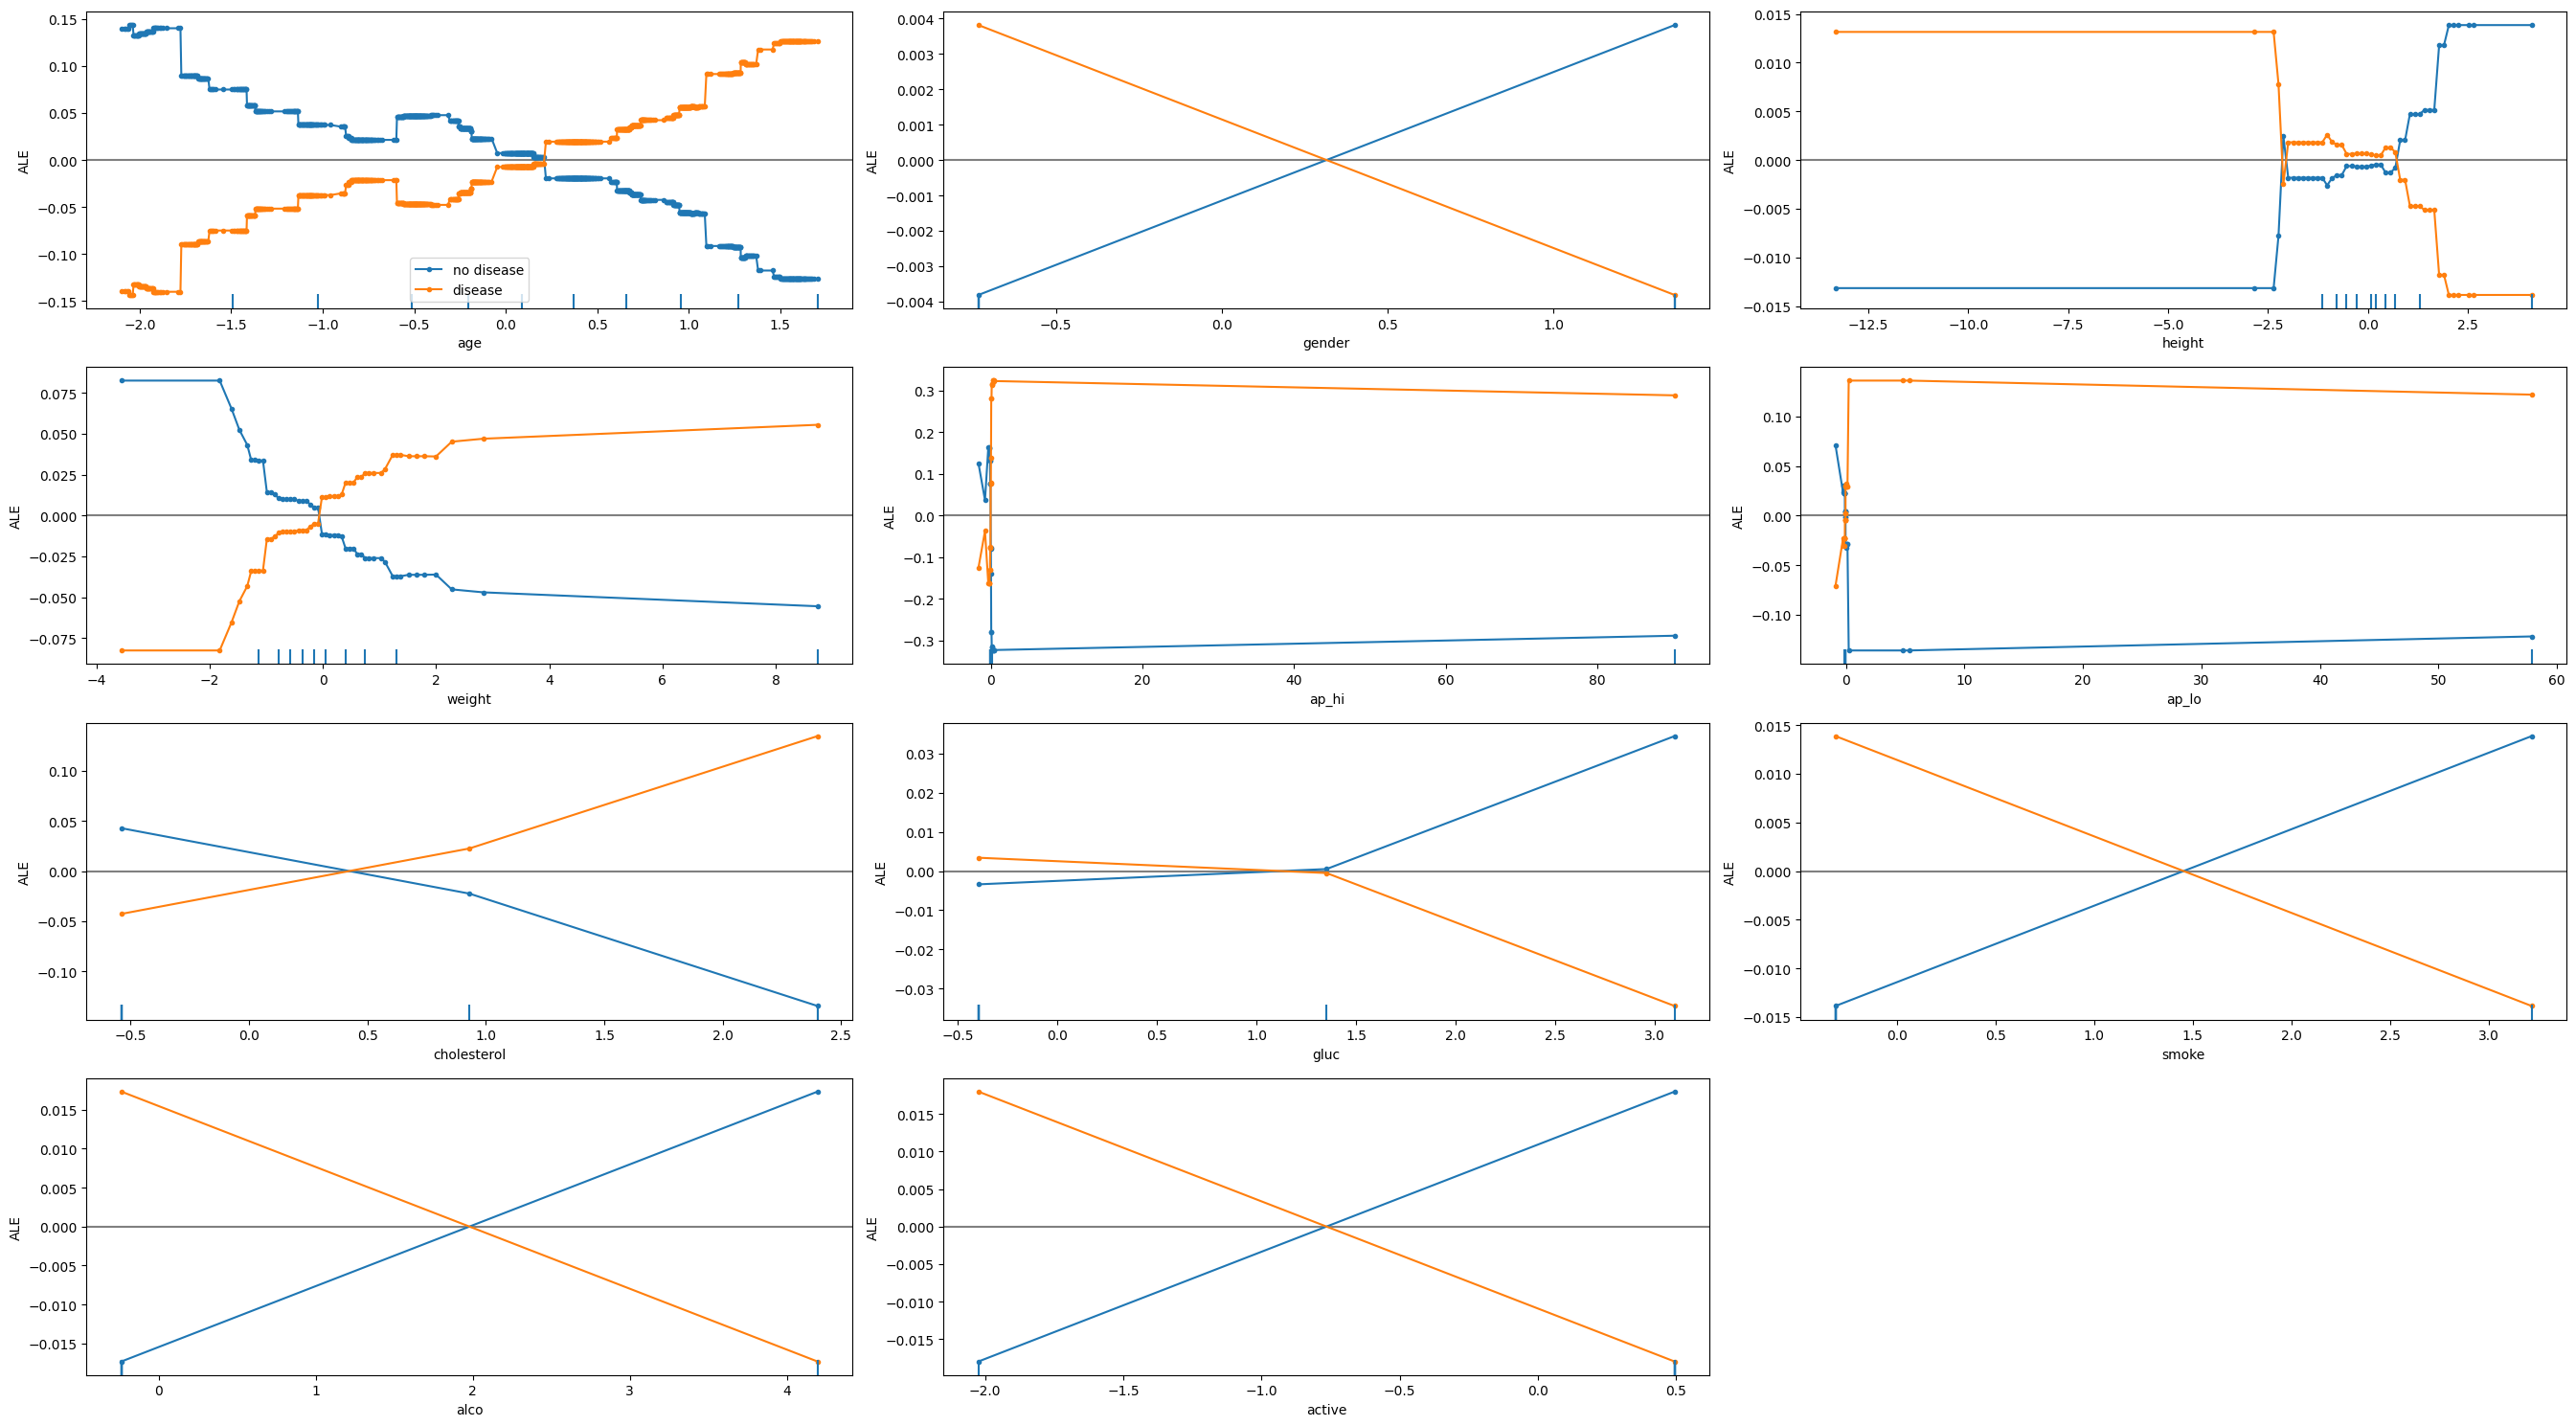

In [ ]:
ALEprob= ALE(prob,feature_names=feature)
exp = ALEprob.explain(x_test2)
plot_ale(exp, targets=[0, 1], line_kw={"label": ["no disease", "disease"]},fig_kw={'figwidth': 27, 'figheight': 15}, sharey=None);

In [ ]:
x_train = np.array(x_train2)
x_test = np.array(x_test2)

explainer = LimeTabularExplainer( training_data=x_train,feature_names=feature,class_names=['no_disease', 'disease'],mode='classification')

i = 0

def predict_fn(x):
    return np.stack([1 - model.predict(np.expand_dims(x, axis=2)).flatten(),model.predict(np.expand_dims(x, axis=2)).flatten()], axis=1)

explanation = explainer.explain_instance(
    data_row= x_test[i],predict_fn=predict_fn,num_features=10)

explanation.show_in_notebook()


157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
